# Segmentation RFM et Clustering afin de permettre la mise en place de stratégie marketing optimales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1) Exploration de la base de données : 

In [2]:
Df = pd.read_csv("C:/Users/nithi/Online_retail-rfm-segmentation/data/raw/online_retail_II.csv")

In [3]:
print(Df.shape)

(1067371, 8)


In [4]:
Df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [5]:
Df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
Df.duplicated().sum()

np.int64(34335)

In [7]:
Df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

On remarque qu'il y a environ 250 000 ID Client qui sont manquantes, représentant près d'un quart des ID Client totaux.

On vérifie qu'il n'y a pas d'incohérence dans les dates des factures (ex : 1900-01-01)

In [8]:
Df['InvoiceDate'].min(), Df['InvoiceDate'].max()

('2009-12-01 07:45:00', '2011-12-09 12:50:00')

In [9]:
Df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


On remarque la présence de quantités et de prix négatifs ce qui peut correspondre aux retour ou aux annulations de commande. Nous allons vérifier cette hypothèse ci-dessous, ces lignes ont un Invoice qui commence par la lettre "C".

In [10]:
# Pour les Quantités : 
Df[Df['Quantity'] < 0]['Invoice'].astype(str).str.startswith('C').mean()


np.float64(0.8493681917211329)

L'hypothèse est quasiment vérifié avec 85 % des quantités négatives provenant bien de retour ou d'annulation de commande, vérifions maintenant d'où proviennent les 15% restants.

In [11]:
Df[(Df['Quantity'] < 0) & (~Df['Invoice'].astype(str).str.startswith('C'))].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom


Ce sont des ajustements de stock internes (pertes, casse, erreurs d'inventaire), pas des transactions clients. Elles n'ont ni prix ni client associé, donc aucune valeur pour l'analyse.

In [12]:
Df[Df['Price'] < 0]['Invoice'].astype(str).str.startswith('C').mean()

np.float64(0.0)

Les prix négatifs ne correspondent pas à des annulations de commandes voyons donc voir à quoi elles correspondent concrètement : 

In [20]:
(Df['Price'] < 0).sum()

np.int64(5)

In [19]:
Df[Df['Price'] < 0][['StockCode', 'Description', 'Quantity', 'Price']]

,StockCode,Description,Quantity,Price
179403,B,Adjust bad debt,1,-53594.36
276274,B,Adjust bad debt,1,-44031.79
403472,B,Adjust bad debt,1,-38925.87
825444,B,Adjust bad debt,1,-11062.06
825445,B,Adjust bad debt,1,-11062.06


Ce résultat nous prouve que les prix négatifs dans la base de donnée correspondent à des écritures comptable de régularisation confirmé par la présence de la description "Adjust bad debt" donc pas une vente.

### 1.4) Distribution des variables : 

Nous allons maintenant analyser les Outliers (valeurs extrêmes), qui peuvent venir biaiser notre analyse. Dans un premier temps, visualison les outliers des colonnes quantités et prix à travers les graphiques suivants : des histogrammes pour analyser la distribution des quantités et des prix et une boîte à moustache (boxplot) pour analyser leurs dispersions.

<Axes: xlabel='Quantity', ylabel='Count'>

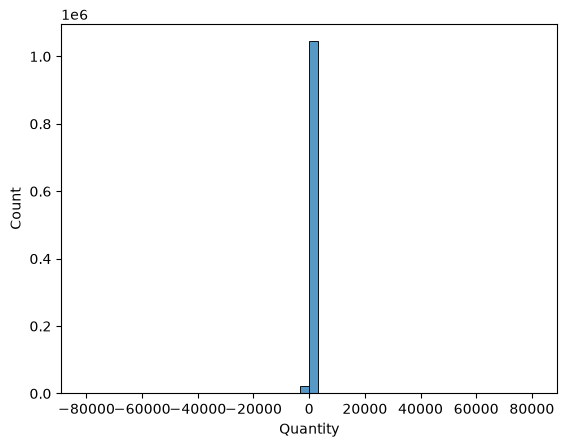

In [14]:
sns.histplot(Df['Quantity'], bins=50)

Le graphique est illisible parce que la distribution est extrêmement concentrée près de zéro avec quelques valeurs extrêmes qui étirent l'axe X jusqu'à 80 000 et - 80 000. On va donc zoomer sur la zone dense pour avoir quelque chose de plus lisible.

<Axes: xlabel='Quantity', ylabel='Count'>

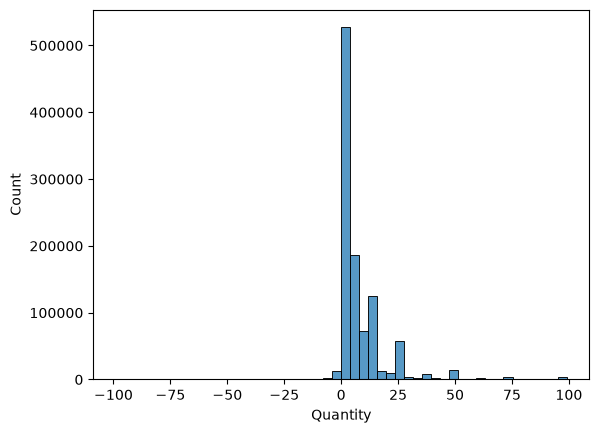

In [15]:
sns.histplot(Df[(Df['Quantity'] > -100) & (Df['Quantity'] < 100)]['Quantity'], bins=50)

La distribution des quantités nous montre que la majorité des transactions concernent de faibles volume (- de 25) avec tout de même la présence de quelques grosses quantités qui tirent la distribution vers des niveaux élevés.

<Axes: xlabel='Price', ylabel='Count'>

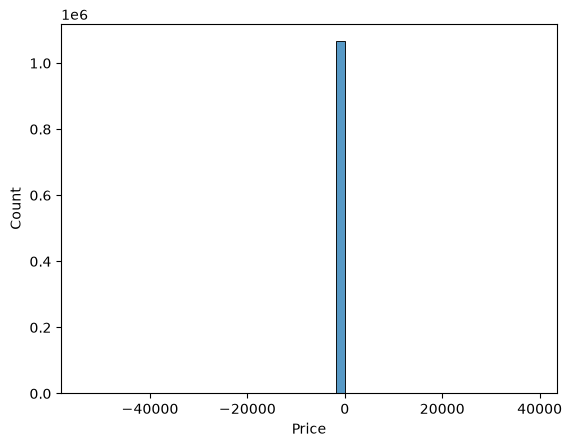

In [16]:
sns.histplot(Df['Price'], bins=50)

On va faire de même pour les Prix.

<Axes: xlabel='Price', ylabel='Count'>

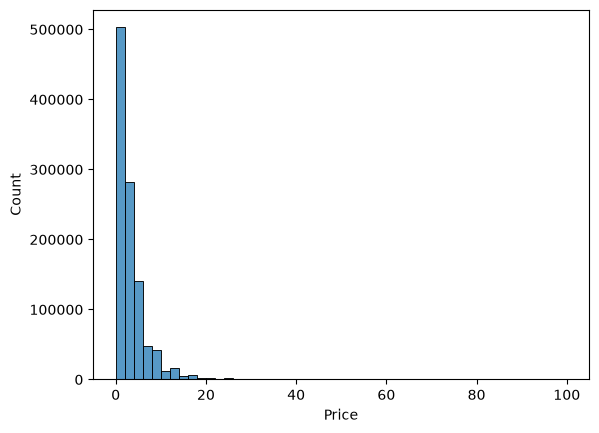

In [17]:
sns.histplot(Df[(Df['Price'] > -100) & (Df['Price'] < 100)]['Price'], bins=50)

La distribution des prix est également fortement concentrée sur des valeurs faibles, avec une asymétrie positive ce qui nous confirme la présence de produits à forte valeur mais peu fréquent dans les transactions.

Les variables Quantités et Prix présentent tous les deux une asymétrie positive qui sont caractérisées par une majorité de faibles valeurs et la présence de valeurs extrêmes qui tirent la distribution vers des niveaux élevés.

<Axes: >

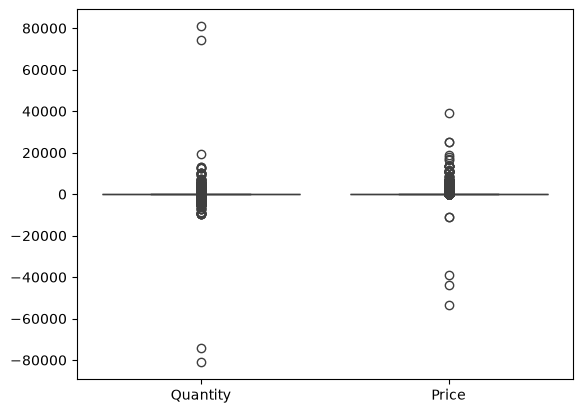

In [18]:
sns.boxplot(data=Df[['Quantity','Price']])

Le boxplot nous confirme la présence d'outliers avec la présences de plusieurs valeurs extrêmes au dessus et en dessous des bopites, les outliers écrasent la visualisation ce qui fait qu'on arrive pas à déceler un comportement normal et donc de dégager des tendances.

Identifions clairement ce que représentent ces outliers, afin de savoir si ceux sont majoriairement les mêmes ID Clients qui reviennent avec des grosses quantités récurrentes ou s'ils s'agissent d'achats ponctuels.

In [19]:
Df[Df['Quantity'] > 1000].sort_values('Quantity', ascending=False).head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.10,13902.0,Denmark
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark
127169,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.10,13902.0,Denmark
1027583,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256.0,United Kingdom
127167,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.10,13902.0,Denmark
192197,507637,84016,FLAG OF ST GEORGE CAR FLAG,10200,2010-05-10 14:55:00,0.00,NaN,United Kingdom
135030,502269,21981,PACK OF 12 WOODLAND TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom


Nous remarquons qu'il y a un mélange des deux options, des achats récurrents effectués par les mêmes clients (même ID Client) ainsi que des achats ponctuel effectué par un seul client. Nous allons les garder dans notre analyse car ils répresentent un comportement d'achat réel et que nous adapterons par la suite notamment pour le clustering. Cependant nous remarquons egalement l'existence de prix = 0, regardant ce que cela signifie.

In [20]:
Df[Df['Price'] == 0].shape

(6202, 8)

In [21]:
Df[Df['Price'] == 0]['Customer ID'].isna().mean()

np.float64(0.9885520799742019)

Ces analyses confirment que ce ne sont quasiment jamais de vraies transactions clients donc probablement des erreurs de saisie, l'ID Client étant quasi-systématiquement absent (98 % des transaction avec comme prix = 0).

In [22]:
Df[Df['Customer ID'] == 12346].sort_values('InvoiceDate')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
27994,491725,TEST001,This is a test product.,10,2009-12-14 08:34:00,4.50,12346.0,United Kingdom
28251,491742,TEST001,This is a test product.,5,2009-12-14 11:00:00,4.50,12346.0,United Kingdom
28254,491744,TEST001,This is a test product.,5,2009-12-14 11:02:00,4.50,12346.0,United Kingdom
39398,492718,TEST001,This is a test product.,5,2009-12-18 10:47:00,4.50,12346.0,United Kingdom
39411,492722,TEST002,This is a test product.,1,2009-12-18 10:55:00,1.00,12346.0,United Kingdom
45228,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346.0,United Kingdom
45230,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346.0,United Kingdom
56117,494450,TEST001,This is a test product.,5,2010-01-14 13:50:00,4.50,12346.0,United Kingdom
66084,495295,TEST001,This is a test product.,5,2010-01-22 13:30:00,4.50,12346.0,United Kingdom
71080,C495800,ADJUST,Adjustment by john on 26/01/2010 17,-1,2010-01-26 17:27:00,103.50,12346.0,United Kingdom


L'analyse du client 12346 nous révèle que ce compte contenait des produits de test et un achat massif annulé. Nous allons donc identifier toutes les valeurs de StockCode qui ne sont pas des produits. Les achats qui sont concernés par une annulation de commande seront enlevés de la base de données dans la partie suivante pour éviter de les incorporer dans notre analyse.

Nous allons d'abord identifier toutes les valeurs de StockCode qui ne sont pas numérique afin de les exclure de notre analyse dans la partie suivante lors du nettoyage de la base de données.

In [24]:
Df['StockCode'].astype(str).apply(lambda x: not x[:5].isdigit()).sum()
Df[Df['StockCode'].astype(str).apply(lambda x: not x[:5].isdigit())]['StockCode'].unique()

<StringArray>
[        'POST',            'D',     'DCGS0058',     'DCGS0068',
          'DOT',            'M',     'DCGS0004',     'DCGS0076',
           'C2', 'BANK CHARGES',     'DCGS0003',      'TEST001',
 'gift_0001_80',     'DCGS0072', 'gift_0001_20',     'DCGS0044',
      'TEST002', 'gift_0001_10', 'gift_0001_50',    'DCGS0066N',
 'gift_0001_30',         'PADS',       'ADJUST', 'gift_0001_40',
 'gift_0001_60', 'gift_0001_70', 'gift_0001_90',    'DCGSSGIRL',
     'DCGS0006',     'DCGS0016',     'DCGS0027',     'DCGS0036',
     'DCGS0039',     'DCGS0060',     'DCGS0056',     'DCGS0059',
         'GIFT',     'DCGSLBOY',            'm',     'DCGS0053',
     'DCGS0062',     'DCGS0037',     'DCGSSBOY',    'DCGSLGIRL',
            'S',     'DCGS0069',     'DCGS0070',     'DCGS0075',
            'B',     'DCGS0041',      'ADJUST2',           'C3',
       'SP1002',    'AMAZONFEE',     'DCGS0055',     'DCGS0074',
     'DCGS0057',     'DCGS0073',     'DCGS0071',    'DCGS0066P',
     'DCGS0

Cela nous permet de voir qu'effectivement certains codes ne concernent pas l'achat de produits par les clients mais des codes administratifs comme ("ADJUST", "BANK CHARGES", "TEST001", "D" = Discount ...). Cependant certains codes comme ("DCGS0003", "DCGSGIRL", "GIFT", ...) méritent une analyse plus poussée afin d'eviter de les enlever alors qu'ils feraient références à de achats de produits comme des cartes cadeaux ce qui fausserait notre analyse. 

Dans le code ci-dessous nous allons donc vérifier si la colonne "Description" contient un vrai nom de produit plutôt que du texte administratif, si la colonne "Prix" a des valeurs cohérentes (ex : pas de 0) et enfin si le Le Customer ID est renseigné normalement.

In [25]:
suspect_codes = ['DCGS0003', 'DCGS0044', 'DCGSSGIRL', 'GIFT', 'gift_0001_20']

for code in suspect_codes:
    print(f"--- {code} ---")
    print(Df[Df['StockCode'] == code][['Description', 'Quantity', 'Price']].describe())
    print(Df[Df['StockCode'] == code]['Description'].unique())
    print()

--- DCGS0003 ---
        Quantity      Price
count  14.000000  14.000000
mean    0.428571   2.327857
std     2.138090   0.670490
min    -7.000000   0.000000
25%     1.000000   2.510000
50%     1.000000   2.510000
75%     1.000000   2.510000
max     1.000000   2.570000
<StringArray>
['BOXED GLASS ASHTRAY', 'ebay']
Length: 2, dtype: str

--- DCGS0044 ---
       Quantity  Price
count       1.0   1.00
mean        1.0   2.57
std         NaN    NaN
min         1.0   2.57
25%         1.0   2.57
50%         1.0   2.57
75%         1.0   2.57
max         1.0   2.57
<StringArray>
['HANDZ-OFF CAR FRESHENER']
Length: 1, dtype: str

--- DCGSSGIRL ---
         Quantity     Price
count   25.000000  25.00000
mean     7.640000   2.97320
std     19.616914   0.98636
min     -1.000000   0.00000
25%      1.000000   3.29000
50%      3.000000   3.29000
75%      5.000000   3.36000
max    100.000000   3.36000
<StringArray>
[nan, 'update', 'GIRLS PARTY BAG']
Length: 3, dtype: str

--- GIFT ---
       Quantity  P

Ces codes contiennent à la fois de vrais produits et du bruit administratif. Par exemple "DCGS00003" contient dans la description "BOXED GLASS ASHTRAY" qui est un vrai produit et "ebay" qui est quant à lui une note interne donc pas un produit. "gift_0001_20" fait bien référence à l'achat de carte cadeaux avec comme description "Dotcomgiftshop Gift Voucher...". 

La stratégie a adopté dans la partie suivante qui va concerner le nettoyage de la base est donc la suivante : Les codes sans ambiguîté (qui ne sont pas des produits) seront exclu par "StockCode" et les codes suspects seront exclus par la colonne "Description" pour éviter d'effacer le code entier puisqu'ils contiennent également de vrais produits.

## 2) Nettoyage de la Base de données : 

Règles de Nettoyage